In [2]:
import os

input_folder = "/kaggle/input/datasets/muhajav2/dataset/datasets_overexposure/val2017"
output_folder = "/kaggle/input/datasets/muhajav2/dataset/datasets_overexposure/overexposed"

print("Input:", input_folder)
print("Output:", output_folder)

Input: /kaggle/input/datasets/muhajav2/dataset/datasets_overexposure/val2017
Output: /kaggle/input/datasets/muhajav2/dataset/datasets_overexposure/overexposed


In [3]:
!pip install opencv-python

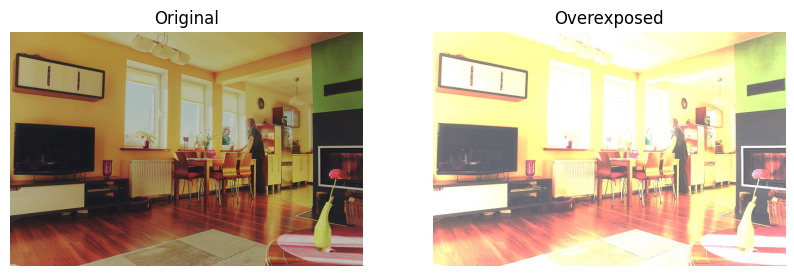

In [4]:
import matplotlib.pyplot as plt
import cv2

sample = "000000000139.jpg"

original_path = os.path.join(input_folder, sample)
over_path = os.path.join(output_folder, sample)

img1 = cv2.imread(original_path)
img2 = cv2.imread(over_path)

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img1)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Overexposed")
plt.imshow(img2)
plt.axis("off")

plt.show()

In [5]:
!pip install torch torchvision scikit-image

In [6]:
original_dir = "/kaggle/input/datasets/muhajav2/dataset/datasets_overexposure/val2017"
overexposed_dir = "/kaggle/input/datasets/muhajav2/dataset/datasets_overexposure/overexposed"

import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class ExposureDataset(Dataset):

    def __init__(self, input_dir, target_dir):

        self.input_dir = input_dir
        self.target_dir = target_dir

        self.images = sorted(list(
            set(os.listdir(input_dir)) & set(os.listdir(target_dir))
        ))

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((256,256)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        filename = self.images[idx]

        input_path = os.path.join(self.input_dir, filename)
        target_path = os.path.join(self.target_dir, filename)

        input_img = cv2.imread(input_path)
        target_img = cv2.imread(target_path)

        input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)

        input_img = self.transform(input_img)
        target_img = self.transform(target_img)

        return input_img, target_img

In [7]:
from torch.utils.data import DataLoader

dataset = ExposureDataset(overexposed_dir, original_dir)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

In [8]:
import matplotlib.pyplot as plt

inputs, targets = next(iter(loader))

print(inputs.shape)

torch.Size([16, 3, 256, 256])


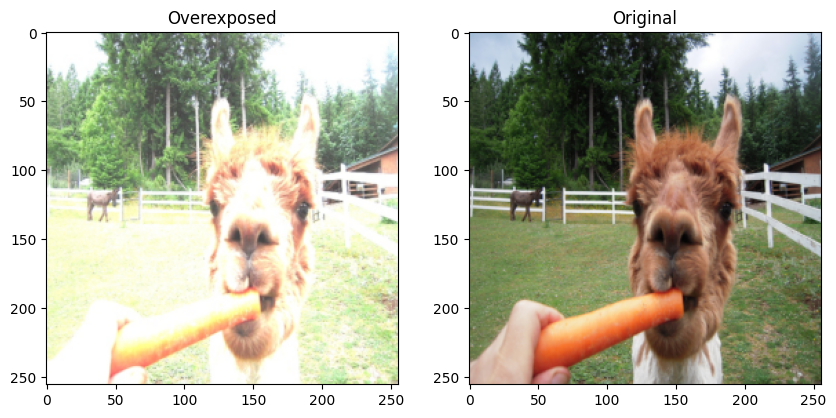

In [9]:
img_input = inputs[0].permute(1,2,0).numpy()
img_target = targets[0].permute(1,2,0).numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Overexposed")
plt.imshow(img_input)

plt.subplot(1,2,2)
plt.title("Original")
plt.imshow(img_target)

plt.show()

In [10]:
import numpy as np

def gamma_correction(img, gamma=0.5):

    img = img.numpy().transpose(1,2,0)

    invGamma = 1.0 / gamma

    table = np.array([
        ((i / 255.0) ** invGamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    img = (img * 255).astype("uint8")

    result = cv2.LUT(img, table)

    return result

In [11]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [12]:
import torch
import torch.nn as nn

class AutoEncoder(nn.Module):

    def __init__(self):
        super(AutoEncoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoEncoder().to(device)

print(device)

cuda


In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
import os

input_files = set(os.listdir(input_folder))
target_files = set(os.listdir(output_folder))

print("Input images:", len(input_files))
print("Target images:", len(target_files))

missing = input_files - target_files
print("Missing targets:", len(missing))

print(list(missing)[:10])

Input images: 5104
Target images: 5104
Missing targets: 104
['000000170613(1).jpg', '000000091406(1).jpg', '000000383289(1).jpg', '000000289586(1).jpg', '000000395633(1).jpg', '000000356505(1).jpg', '000000575187(1).jpg', '000000267300(1).jpg', '000000383339(1).jpg', '000000377670(1).jpg']


In [16]:
num_epochs = 10

for epoch in range(num_epochs):

    running_loss = 0.0

    for inputs, targets in loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(loader):.4f}")

Epoch [1/10], Loss: 0.0292
Epoch [2/10], Loss: 0.0185
Epoch [3/10], Loss: 0.0168
Epoch [4/10], Loss: 0.0164
Epoch [5/10], Loss: 0.0158
Epoch [6/10], Loss: 0.0158
Epoch [7/10], Loss: 0.0149
Epoch [8/10], Loss: 0.0141
Epoch [9/10], Loss: 0.0147
Epoch [10/10], Loss: 0.0142


In [17]:
inputs, targets = next(iter(loader))

inputs = inputs.to(device)

with torch.no_grad():
    outputs = model(inputs)

In [19]:
inputs, targets = next(iter(loader))

inputs = inputs.to(device)

with torch.no_grad():
    outputs = model(inputs)

input_img = inputs[0].cpu().permute(1,2,0).numpy()
target_img = targets[0].permute(1,2,0).numpy()
output_img = outputs[0].cpu().permute(1,2,0).numpy()

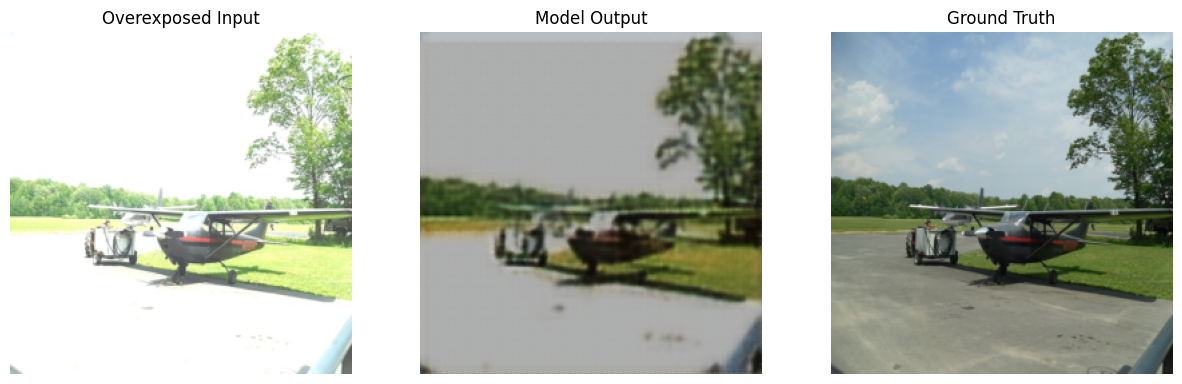

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Overexposed Input")
plt.imshow(input_img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Model Output")
plt.imshow(output_img)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Ground Truth")
plt.imshow(target_img)
plt.axis("off")

plt.show()

In [21]:
torch.save(model.state_dict(), "exposure_autoencoder.pth")